# 🛡️ Anomaly Detection — One-Class SVM (SGD)
## CSE-CIC-IDS2018 Dataset | AWS t3.large Optimized | With Full Caching

**Project Goal:** Train a One-Class SVM exclusively on **benign network traffic** to learn the boundary of "normal" behavior. Any traffic falling outside this boundary is flagged as an anomaly (intrusion), enabling the detection of **unseen zero-day attacks**.

**Pipeline Overview:**
1. Load & merge all 10 CSVs → cached as `cleaned_data.parquet`
2. Clean & preprocess features → cached in parquet
3. **Benign-Only Training Split** → cached as `.npy` arrays
4. Train `SGDOneClassSVM` → cached as `.joblib` model
5. Compute anomaly scores → cached as `.npy` arrays
6. Evaluate & visualize (Score Distribution, ROC/PR Curves, Confusion Matrix)

**Environment:** Ubuntu 24.04 | EC2 t3.large | 8GB RAM + 16GB swap | Python 3.10+

## Cell 1 — Install / Verify Dependencies

In [1]:
import sys, platform, os
import numpy as np
import pandas as pd
import sklearn, matplotlib, seaborn

print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Scikit     : {sklearn.__version__}")

mem_bytes = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print(f"\nSystem RAM : {mem_bytes / (1024**3):.1f} GB")

Python     : 3.12.3
NumPy      : 2.4.4
Pandas     : 3.0.2
Scikit     : 1.8.0

System RAM : 7.6 GB


## Cell 2 — Configuration & Cache Paths

In [2]:
import os
from pathlib import Path

DATA_PATH  = os.path.expanduser("~/ids2018/data")
OUTPUT_DIR = os.path.expanduser("~/ids2018/outputs")
CACHE_DIR  = os.path.expanduser("~/ids2018/cache")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,  exist_ok=True)

CACHE_PARQUET      = os.path.join(CACHE_DIR, "cleaned_data.parquet")
CACHE_X_TRAIN      = os.path.join(CACHE_DIR, "ocsvm_X_train.npy")
CACHE_X_VAL        = os.path.join(CACHE_DIR, "ocsvm_X_val.npy")
CACHE_X_ALL        = os.path.join(CACHE_DIR, "ocsvm_X_all.npy")
CACHE_Y_ALL        = os.path.join(CACHE_DIR, "ocsvm_y_all.npy")
CACHE_LABELS_ALL   = os.path.join(CACHE_DIR, "ocsvm_labels_all.npy")
CACHE_SCALER       = os.path.join(CACHE_DIR, "ocsvm_scaler.joblib")
CACHE_MODEL        = os.path.join(OUTPUT_DIR, "ocsvm_model.joblib")

FORCE_RERUN = False
SEED = 42

# ── OCSVM Hyperparameters ───────────────────────────────────────────────────
NU                   = 0.05    # Upper bound on fraction of training errors (~5% outliers expected in clean data)
THRESHOLD_PERCENTILE = 99      # P99 = ~1% FPR on benign validation set

print(f"Data path  : {DATA_PATH}")
print(f"FORCE_RERUN: {FORCE_RERUN}")

Data path  : /home/ubuntu/ids2018/data
FORCE_RERUN: False


## Cell 3 — Imports & Helpers

In [3]:
import warnings, gc, time, joblib
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.linear_model import SGDOneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.switch_backend("Agg")
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.1)

def save_and_show(fig, filename: str):
    save_path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=save_path))

def cache_exists(*paths) -> bool:
    if FORCE_RERUN: return False
    return all(os.path.exists(p) for p in paths)

print("Helpers ready ✓")

Helpers ready ✓


## Stage 1+2: Load & Clean *(Shared Logic)*

In [4]:
if cache_exists(CACHE_PARQUET):
    print(f"CACHE HIT — loading cleaned data: {CACHE_PARQUET}")
    df = pd.read_parquet(CACHE_PARQUET)
else:
    print("CACHE MISS — please run autoencoder_model.ipynb first to generate cleaned_data.parquet")
    raise FileNotFoundError(CACHE_PARQUET)

print(f"Loaded {len(df):,} rows.")

CACHE HIT — loading cleaned data: /home/ubuntu/ids2018/cache/cleaned_data.parquet
Loaded 3,215,110 rows.


## Stage 3 — Split & Scale *(Benign-Only Training)*

In [5]:
STAGE3_FILES = [CACHE_X_TRAIN, CACHE_X_VAL, CACHE_X_ALL, CACHE_Y_ALL, CACHE_LABELS_ALL, CACHE_SCALER]

if cache_exists(*STAGE3_FILES):
    print("CACHE HIT — loading scaled arrays...")
    X_train_scaled = np.load(CACHE_X_TRAIN)
    X_val_scaled   = np.load(CACHE_X_VAL)
    X_all_scaled   = np.load(CACHE_X_ALL)
    y_all          = np.load(CACHE_Y_ALL)
    labels_all     = np.load(CACHE_LABELS_ALL, allow_pickle=True)
    scaler         = joblib.load(CACHE_SCALER)
else:
    print("CACHE MISS — splitting and scaling...")
    
    LABEL_COL = "Label"
    if LABEL_COL not in df.columns: LABEL_COL = "label"
    
    FEATURE_COLS = [c for c in df.columns if c not in [LABEL_COL, "is_attack", "attack_type"]]
    
    # Standardize labels
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.lower().str.strip()
    y_all      = (df[LABEL_COL] != "benign").astype(int).values
    labels_all = df[LABEL_COL].values
    X_values   = df[FEATURE_COLS].values.astype(np.float32)
    
    # Split benign traffic for training/validation
    benign_idx = np.where(y_all == 0)[0]
    train_idx, val_benign_idx = train_test_split(benign_idx, test_size=0.2, random_state=SEED)
    
    print(f"Fitting RobustScaler on {len(train_idx):,} benign samples...")
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_values[train_idx])
    X_val_scaled   = scaler.transform(X_values[val_benign_idx])
    X_all_scaled   = scaler.transform(X_values)
    
    # Clip to reduce outlier impact during SGD
    CLIP = 10.0
    X_train_scaled = np.clip(X_train_scaled, -CLIP, CLIP)
    X_val_scaled   = np.clip(X_val_scaled,   -CLIP, CLIP)
    X_all_scaled   = np.clip(X_all_scaled,   -CLIP, CLIP)
    
    print("Saving scaled arrays...")
    np.save(CACHE_X_TRAIN,    X_train_scaled)
    np.save(CACHE_X_VAL,      X_val_scaled)
    np.save(CACHE_X_ALL,      X_all_scaled)
    np.save(CACHE_Y_ALL,      y_all)
    np.save(CACHE_LABELS_ALL, labels_all)
    joblib.dump(scaler,       CACHE_SCALER)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_all  : {X_all_scaled.shape}")

CACHE MISS — splitting and scaling...
Fitting RobustScaler on 1,640,626 benign samples...
Saving scaled arrays...
X_train: (1640626, 68)
X_all  : (3215110, 68)


## Stage 4 — Train SGD One-Class SVM

In [6]:
if cache_exists(CACHE_MODEL):
    print("CACHE HIT — loading OCSVM model...")
    ocsvm = joblib.load(CACHE_MODEL)
else:
    print(f"CACHE MISS — training SGDOneClassSVM (nu={NU})...")
    # SGDOneClassSVM provides an online linear One-Class SVM that scales to millions of rows.
    ocsvm = SGDOneClassSVM(
        nu=NU,
        shuffle=True,
        random_state=SEED,
        verbose=1
    )
    
    t0 = time.time()
    ocsvm.fit(X_train_scaled)
    print(f"Training took {time.time()-t0:.1f}s")
    
    print("Saving model...")
    joblib.dump(ocsvm, CACHE_MODEL)

print("OCSVM Model ready.")

CACHE MISS — training SGDOneClassSVM (nu=0.05)...
-- Epoch 1
Norm: 2.37, NNZs: 66, Bias: -3.087911, T: 1640626, Avg. loss: 0.035121, Objective: -0.041042
Total training time: 0.93 seconds.
-- Epoch 2
Norm: 2.42, NNZs: 66, Bias: -3.217252, T: 3281252, Avg. loss: 0.041751, Objective: -0.044565
Total training time: 1.71 seconds.
-- Epoch 3
Norm: 2.43, NNZs: 66, Bias: -3.282938, T: 4921878, Avg. loss: 0.043874, Objective: -0.045026
Total training time: 2.47 seconds.
-- Epoch 4
Norm: 2.44, NNZs: 66, Bias: -3.328047, T: 6562504, Avg. loss: 0.045013, Objective: -0.045285
Total training time: 3.19 seconds.
-- Epoch 5
Norm: 2.49, NNZs: 66, Bias: -3.364143, T: 8203130, Avg. loss: 0.045841, Objective: -0.045452
Total training time: 3.90 seconds.
-- Epoch 6
Norm: 2.46, NNZs: 66, Bias: -3.390945, T: 9843756, Avg. loss: 0.046310, Objective: -0.045597
Total training time: 4.72 seconds.
-- Epoch 7
Norm: 2.44, NNZs: 66, Bias: -3.404040, T: 11484382, Avg. loss: 0.050015, Objective: -0.045568
Total train

## Stage 5 — Scores & Thresholding

In [7]:
print("Calculating anomaly scores (decision function)...")
# Note: decision_function returns negative values for outliers.
# We multiply by -1 so higher score = more anomalous.
scores_val = -ocsvm.decision_function(X_val_scaled)
scores_all = -ocsvm.decision_function(X_all_scaled)

threshold = np.percentile(scores_val, THRESHOLD_PERCENTILE)
print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile): {threshold:.4f}")

Calculating anomaly scores (decision function)...
Threshold (99th percentile): 1.0747


## Stage 6 — Evaluation & Visualization

In [8]:
y_pred = (scores_all > threshold).astype(int)

print("--- Overall Anomaly Detection Report ---")
print(classification_report(y_all, y_pred))

auroc = roc_auc_score(y_all, scores_all)
print(f"ROC-AUC: {auroc:.4f}")

--- Overall Anomaly Detection Report ---
              precision    recall  f1-score   support

           0       0.64      0.99      0.78   2050783
           1       0.66      0.04      0.07   1164327

    accuracy                           0.64   3215110
   macro avg       0.65      0.51      0.42   3215110
weighted avg       0.65      0.64      0.52   3215110

ROC-AUC: 0.6844


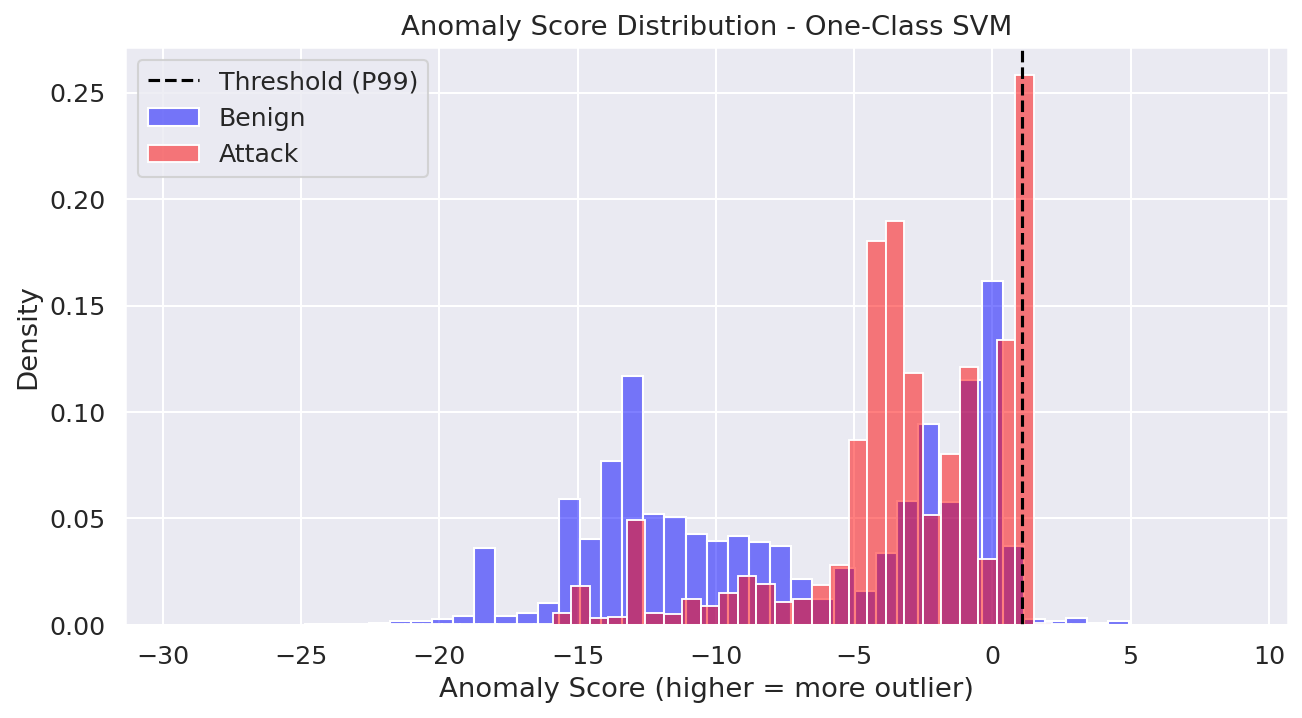

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(scores_all[y_all == 0], bins=50, color="blue", label="Benign", alpha=0.5, stat="density", ax=ax)
sns.histplot(scores_all[y_all == 1], bins=50, color="red", label="Attack", alpha=0.5, stat="density", ax=ax)
ax.axvline(threshold, color="black", linestyle="--", label=f"Threshold (P{THRESHOLD_PERCENTILE})")
ax.set_title("Anomaly Score Distribution - One-Class SVM")
ax.set_xlabel("Anomaly Score (higher = more outlier)")
ax.legend()
save_and_show(fig, "ocsvm_score_dist.png")

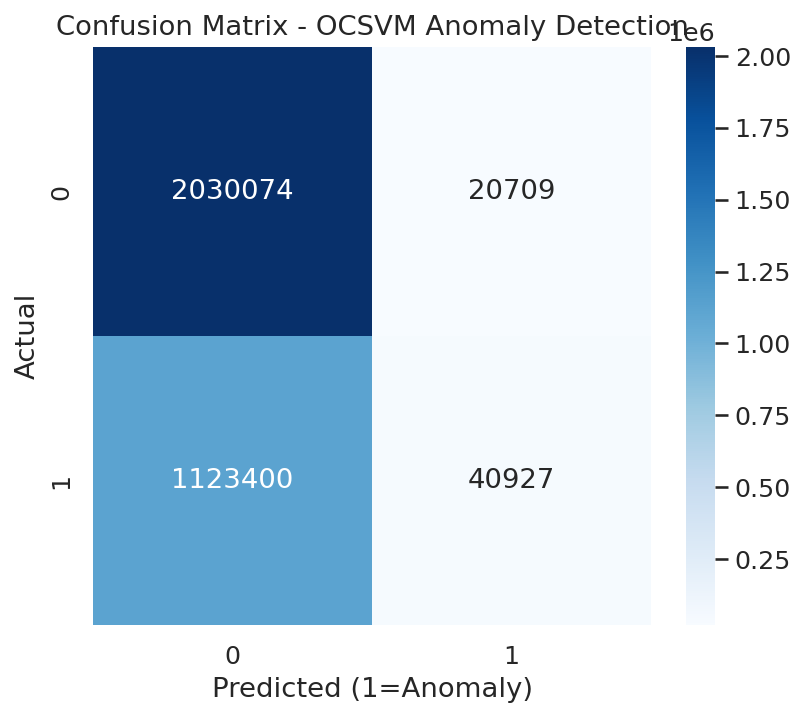

In [10]:
cm = confusion_matrix(y_all, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix - OCSVM Anomaly Detection")
ax.set_xlabel("Predicted (1=Anomaly)")
ax.set_ylabel("Actual")
save_and_show(fig, "ocsvm_confusion_matrix.png")

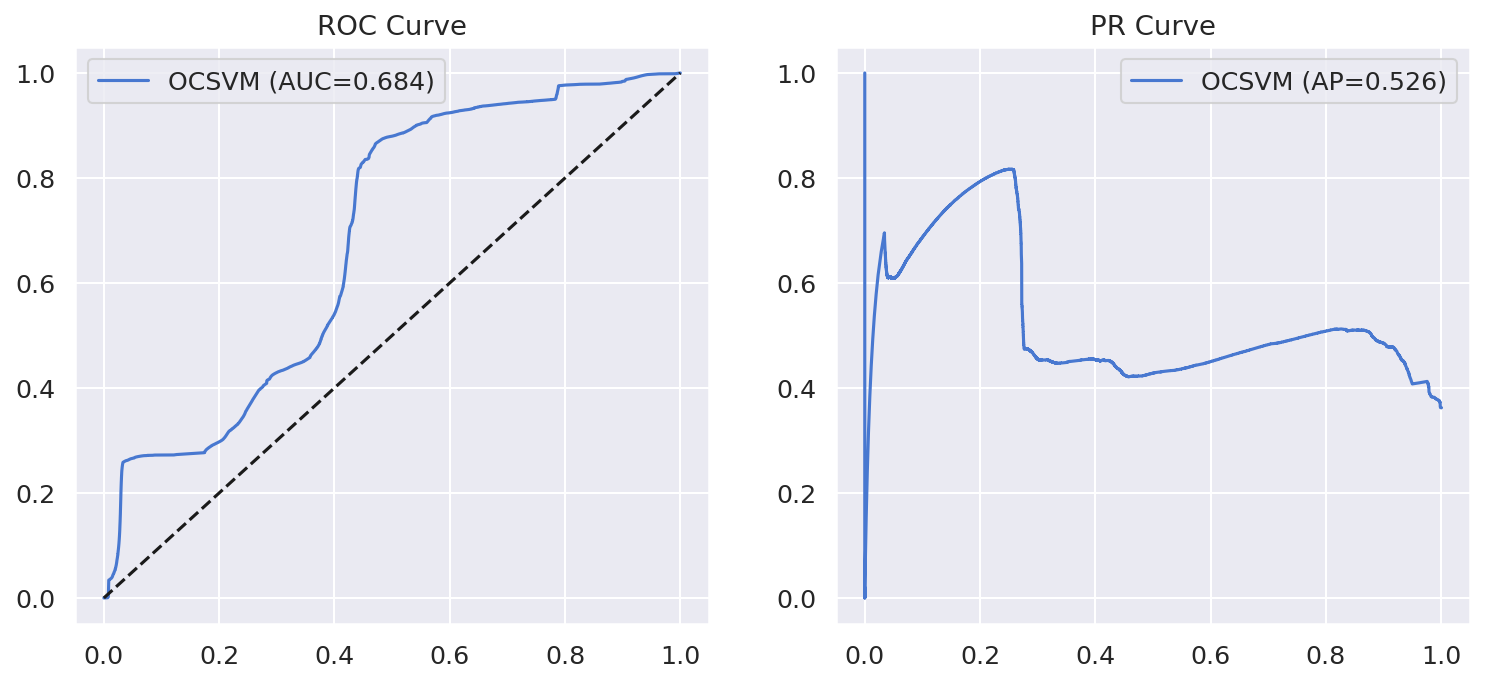

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_all, scores_all)
ax1.plot(fpr, tpr, label=f"OCSVM (AUC={auroc:.3f})")
ax1.plot([0,1],[0,1], 'k--')
ax1.set_title("ROC Curve")
ax1.legend()

prec, rec, _ = precision_recall_curve(y_all, scores_all)
ap = average_precision_score(y_all, scores_all)
ax2.plot(rec, prec, label=f"OCSVM (AP={ap:.3f})")
ax2.set_title("PR Curve")
ax2.legend()

save_and_show(fig, "ocsvm_curves.png")